In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
def include_y(df):
    df = df.copy().reset_index()
    df['Grupo'] = np.where(df['index'].str.contains('A'), 'Tratamiento', 
                np.where(df['index'].str.contains('C'), 'Control', 'Otro'))
    df = df.set_index('index')
    df = pd.get_dummies(df, columns=['Grupo'], drop_first=True)
    df['Grupo_Tratamiento'] = df['Grupo_Tratamiento'].astype(int)
    return df

def sclFromDf(df1,df2):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df1_scl = pd.DataFrame(scaler.fit_transform(df1), columns = df1.columns, index=df1.index)
    #we use theparameters of the standarization of df1 (mean and std) to standarize df2
    df2_scl = pd.DataFrame(scaler.transform(df2), columns = df2.columns, index=df2.index)
    return df1_scl, df2_scl
def discretizar_variables(df, n_bins):
    """
    Discretiza las variables continuas usando una cantidad definida de intervalos.
    """
    df_discretized = df.copy()
    for col in df.columns:
        df_discretized[col] = pd.qcut(df[col], q=n_bins, labels=False, duplicates='drop')
    data_encoded = pd.DataFrame()
    for col in df_discretized.columns:
        dummies = pd.get_dummies(df_discretized[col], prefix=col, prefix_sep='_')
        data_encoded = pd.concat([data_encoded, dummies], axis=1)
    data_encoded = data_encoded.astype(int)

    return data_encoded
def scl(df):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df1_scl = pd.DataFrame(scaler.fit_transform(df), columns = df.columns, index=df.index)
    return df1_scl

In [3]:
#### entrenamiento
lncRNA_entrenamiento = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
lncRNA_entrenamiento = lncRNA_entrenamiento.loc[:, ~lncRNA_entrenamiento.columns.str.contains('Norm')]
lncRNA_entrenamiento = lncRNA_entrenamiento.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T
lncRNA_entrenamiento = lncRNA_entrenamiento[['TNRC6C-AS1', 'H19','MBNL1-AS1']]
lncRNA_entrenamiento.index = lncRNA_entrenamiento.index.str.replace('Raw_', '', regex=False)
#info adicional
lncRNA_entrenamiento_info = pd.read_csv('../mRNA_seq/pacientesInfoAdicional.csv',sep = ';')
lncRNA_entrenamiento_info['Sexo'] = lncRNA_entrenamiento_info['Sexo'].str.lower()
lncRNA_entrenamiento_info['Sexo'] = pd.get_dummies(lncRNA_entrenamiento_info['Sexo']).astype(int)['hombre']
lncRNA_entrenamiento_info['Grupo_Tratamiento'] = pd.get_dummies(lncRNA_entrenamiento_info['Condición']).astype(int)['estenosis aórtica']
lncRNA_entrenamiento_info = lncRNA_entrenamiento_info.drop('Condición', axis = 1).rename(columns = {'ID muestra': 'index'}).set_index('index')
####validacion
lncRNA_validacion = pd.read_excel('../mRNA_seq/Validation lncRNA  H19_TNRC6C_Mbnl1as1 040725.xlsx')
lncRNA_validacion_info = lncRNA_validacion.rename(columns ={ 'Unnamed: 0':'index','sexo' : 'Sexo','normalización' : 'Normalizan'})[['index','Sexo','Normalizan']].dropna(axis=0, how='all').set_index('index')
lncRNA_validacion_info = include_y(lncRNA_validacion_info)
lncRNA_validacion = lncRNA_validacion.reset_index(drop=True).rename(columns ={ 'Tnrc6cas1' : 'TNRC6C-AS1', 'Unnamed: 0':'index','Mbnl1as1':'MBNL1-AS1'}).drop(['normalización','sexo'], axis=1).dropna()
lncRNA_validacion.set_index('index', inplace=True)
#lncRNA_entrenamiento.to_csv('lncRNA_entrenamiento.csv')
#lncRNA_validacion.to_csv('lncRNA_validacion.csv')
######################################### Normalizamos en R
#lncRNA_entrenamiento_LimmaNorm = pd.read_csv('lncRNA_entrenamiento_norm.csv',index_col = 0).set_index(lncRNA_entrenamiento.index)
#lncRNA_validacion_LimmaNorm = pd.read_csv('lncRNA_validacion_norm.csv',index_col = 0).set_index(lncRNA_validacion.index)
#lncRNA_entrenamiento_norm , lncRNA_validacion_norm = sclFromDf(lncRNA_entrenamiento,lncRNA_validacion)

In [4]:
lncRNA_validacion_norm = scl(lncRNA_validacion)
lncRNA_entrenamiento_norm = scl(lncRNA_entrenamiento)

In [5]:
lncRNA_entrenamiento_norm_1 = include_y(lncRNA_entrenamiento_norm)
lncRNA_validacion_norm_1 = include_y(lncRNA_validacion_norm)

### Correlaciones

In [333]:
lncRNA_entrenamiento_norm_1.corr()

,TNRC6C-AS1,H19,MBNL1-AS1,Grupo_Tratamiento
TNRC6C-AS1,1.000000,0.548670,0.434100,0.421139
H19,0.548670,1.000000,0.291611,0.553399
MBNL1-AS1,0.434100,0.291611,1.000000,0.406150
Grupo_Tratamiento,0.421139,0.553399,0.406150,1.000000


In [334]:
lncRNA_validacion_norm_1.corr()

,TNRC6C-AS1,H19,MBNL1-AS1,Grupo_Tratamiento
TNRC6C-AS1,1.000000,0.506059,0.679120,-0.065373
H19,0.506059,1.000000,0.494908,0.460341
MBNL1-AS1,0.679120,0.494908,1.000000,0.077895
Grupo_Tratamiento,-0.065373,0.460341,0.077895,1.000000


#### Distribucición variables boxplot

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_entrenamiento_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


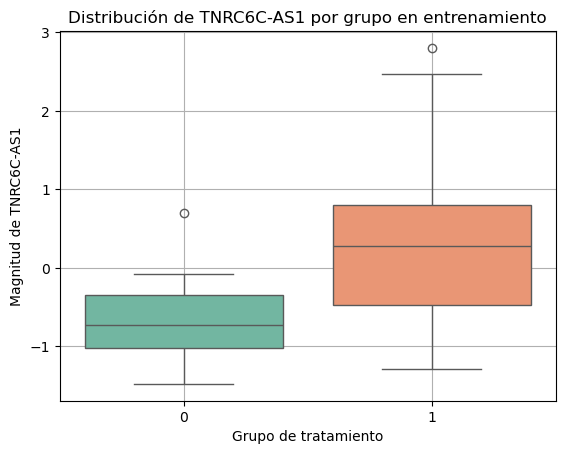

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_entrenamiento_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


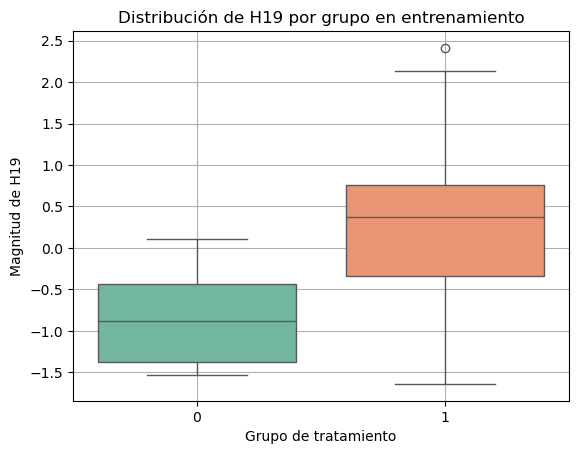

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_entrenamiento_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


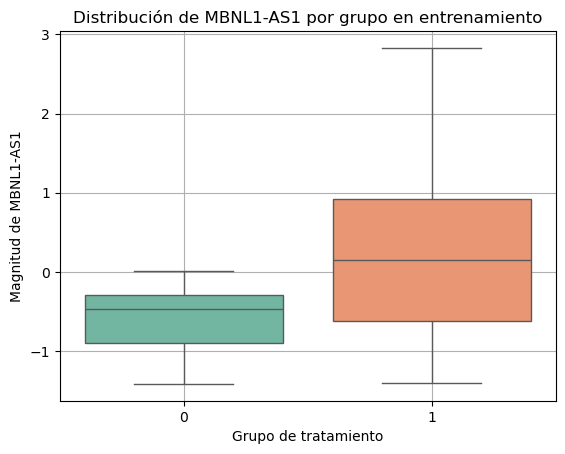

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_validacion_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


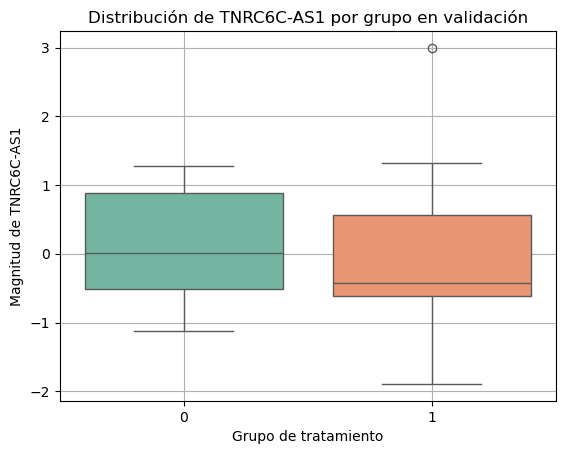

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_validacion_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


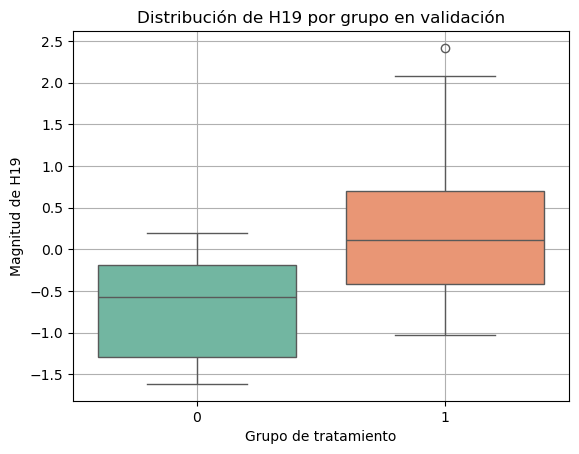

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\delatorrei\AppData\Local\Temp\ipykernel_14472\3763710282.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lncRNA_validacion_norm_1,
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


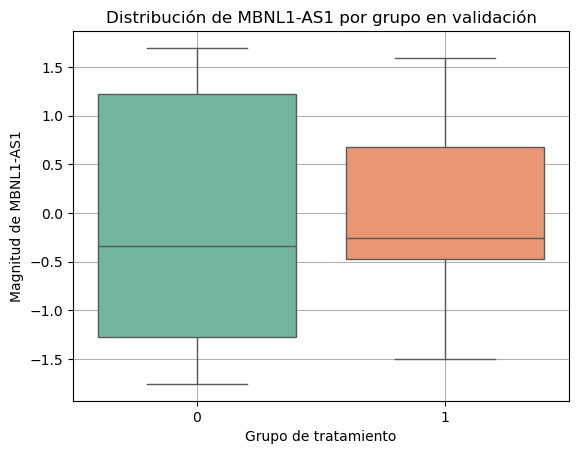

In [336]:
for col in lncRNA_entrenamiento_norm_1.columns:
    if col != 'Grupo_Tratamiento':
        sns.boxplot(data=lncRNA_entrenamiento_norm_1, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2')

        plt.xlabel('Grupo de tratamiento')
        plt.ylabel(f'Magnitud de {col}')
        plt.title(f'Distribución de {col} por grupo en entrenamiento')
        plt.grid(True)
        plt.savefig(f"../graphics/new_boxplot_{col}_gnral.png", bbox_inches='tight', dpi=300)
        plt.show()

for col in lncRNA_validacion_norm_1.columns:
    if col != 'Grupo_Tratamiento':
        sns.boxplot(data=lncRNA_validacion_norm_1, 
                    x='Grupo_Tratamiento', 
                    y=col, 
                    palette='Set2')

        plt.xlabel('Grupo de tratamiento')
        plt.ylabel(f'Magnitud de {col}')
        plt.title(f'Distribución de {col} por grupo en validación')
        plt.savefig(f"../graphics/new_boxplot_{col}_valid.png", bbox_inches='tight', dpi=300)
        plt.grid(True)
        plt.show()

### Tests

In [7]:
def test_diff(df):
    
    from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
    from statsmodels.stats.multitest import multipletests
    df1_trnto =df [df['Grupo_Tratamiento'] == 1].drop('Grupo_Tratamiento', axis = 1)
    df1_ctrl = df[df['Grupo_Tratamiento'] == 0].drop('Grupo_Tratamiento', axis = 1)
    variables = df1_ctrl.columns  
    p_values = []
    tests = []  # Para almacenar qué test se usó en cada variable

    for var in variables:
        # Prueba de normalidad en ambos grupos
        p_value_trnto = shapiro(df1_trnto[var]).pvalue
        p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
        # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
        
        if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
            #Los dos p_values son normales → Usamos T_student
            stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
            test_name = 't-test'
        else:
            # Al menos un grupo no es normal → Usamos Mann-Whitney U
            stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
            test_name = 'Mann-Whitney'

        tests.append(test_name)
        p_values.append(p_value)  # Guardamos el p-valor obtenido

    # Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
    reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

    # Clasificar variables según la corrección FDR
    variablesIncluir = [var for var, r in zip(variables, reject) if r]
    variablesExcluir = [var for var, r in zip(variables, reject) if not r]

    # Guardar los resultados en un DataFrame
    df_resultados = pd.DataFrame({
        'Variable': variables,
        'Test aplicado': tests,
        'p-valor original': p_values,
        'p-valor ajustado (FDR)': p_adjusted,
        'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
    })
    return df_resultados, variablesIncluir, variablesExcluir

In [8]:
df_resultados, variablesIncluir, variablesExcluir =  test_diff(lncRNA_entrenamiento_norm_1)
print("Variables a incluir en el modelo:", variablesIncluir, "Variables a excluir del modelo:", variablesExcluir)
df_resultados

Variables a incluir en el modelo: ['TNRC6C-AS1', 'H19', 'MBNL1-AS1'] Variables a excluir del modelo: []


,Variable,Test aplicado,p-valor original,p-valor ajustado (FDR),Rechazar H0 (FDR)
0,TNRC6C-AS1,t-test,0.002851,0.002851,True
1,H19,t-test,0.000090,0.000270,True
2,MBNL1-AS1,t-test,0.002131,0.002851,True


In [9]:
df_resultados, variablesIncluir, variablesExcluir =  test_diff(lncRNA_validacion_norm_1)
print("Variables a incluir en el modelo:", variablesIncluir, "Variables a excluir del modelo:", variablesExcluir)
df_resultados

Variables a incluir en el modelo: ['H19'] Variables a excluir del modelo: ['TNRC6C-AS1', 'MBNL1-AS1']


,Variable,Test aplicado,p-valor original,p-valor ajustado (FDR),Rechazar H0 (FDR)
0,TNRC6C-AS1,t-test,0.717206,0.741735,False
1,H19,t-test,0.005690,0.017071,True
2,MBNL1-AS1,t-test,0.741735,0.741735,False


### Random Forest

In [6]:
algortms_tasas = {}
importancias = {}

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score,cross_val_predict, train_test_split
from sklearn.metrics  import roc_curve, auc, accuracy_score,confusion_matrix

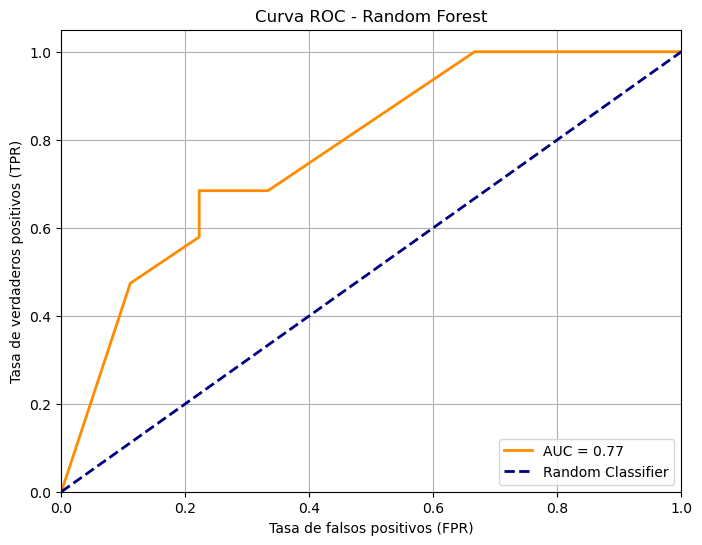

R^2 train: 0.86
R^2 test: 0.68
Accuracy: 0.68
AUC de la curva ROC: 0.7748538011695907
Tasa de verdaderos negativos (TNR - especificidad): 0.6666666666666666
Tasa de falsos negativos (FNR): 0.3157894736842105
Tasa de verdaderos  positivos (TPR): 0.6842105263157895
Tasa de falsos positivos (FPR): 0.3333333333333333
      Feature  Importance
1         H19    0.472045
0  TNRC6C-AS1    0.295771
2   MBNL1-AS1    0.232184


In [8]:
n_estimators = 100
max_depth = 3


X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
X_test = discretizar_variables(X_test, 2)
X_train = X_train.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'})
X_train = X_train[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]
X_test = X_test.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'})
X_test = X_test[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, oob_score=True, random_state=42)


rf.fit(X_train, y_train)

# Predicciones
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]


importances = rf.feature_importances_
feature_names = X_train.columns
feat_importances = pd.DataFrame(importances, index=feature_names).reset_index().rename(columns={'index': 'Feature',0 : 'Importance'}).sort_values(by='Importance', ascending=False)
# Calcular AUC y ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión agregada
cm = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados
# print r square de train y de test:
r_squared = rf.score(X_train, y_train)
print(f'R^2 train: {r_squared:.2f}')
r_squared = rf.score(X_test, y_test)
print(f'R^2 test: {r_squared:.2f}')

accuracies_train = cross_val_score(rf, X_train, y_train)
accuracies_test = cross_val_score(rf, X_test, y_test)
#print("Precisión media en entrenamiento:", np.mean(accuracies_train))
#print("Precisión media en test:", np.mean(accuracies_test))
accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy: {accuracy:.2f}')

print("AUC de la curva ROC:", roc_auc)
print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)
print(feat_importances)


algortms_tasas.update({'Random Forest': {'Accuracy': accuracy,
                                      'AUC': roc_auc, 'R^2 train': r_squared,
                                      'R^2 test': r_squared, 'TNR': TNR,
                                      'FNR': FNR, 'TPR': TPR, 'FPR': FPR}})
importancias.update({'Random Forest': feat_importances}) 

### Logistica

In [9]:
from sklearn.linear_model import LogisticRegression

Accuracy: 0.68
AUC: 0.77
R^2 train: 0.74
R^2 test: 0.68
Tasa de verdaderos negativos (TNR - especificidad): 0.7777777777777778
Tasa de falsos negativos (FNR): 0.3684210526315789
Tasa de verdaderos  positivos (TPR): 0.631578947368421
Tasa de falsos positivos (FPR): 0.2222222222222222


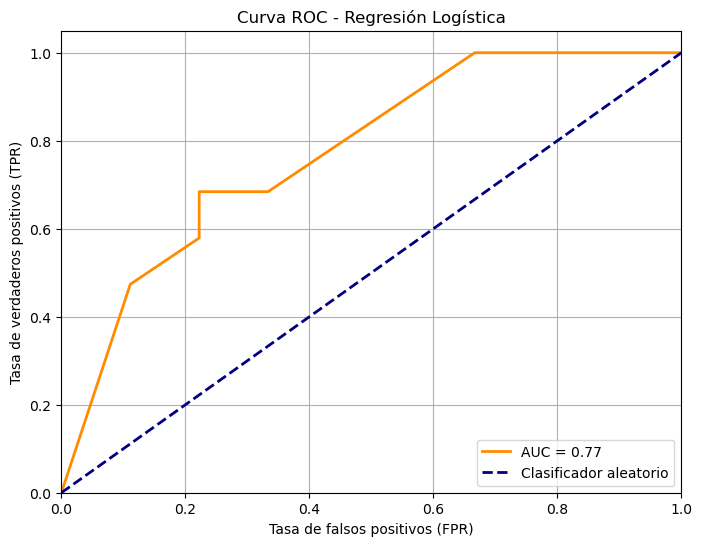

Coeficientes del modelo:
      Feature  Importance
1         H19    0.526075
0  TNRC6C-AS1    0.000000
2   MBNL1-AS1    0.000000


In [10]:
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
X_test = discretizar_variables(X_test, 2)

X_train = X_train.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'})
X_train = X_train[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]
X_test = X_test.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'})
X_test = X_test[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]

log_reg = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', C = 0.3)


# Entrenar el modelo
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1] 

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')




fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)


print(f'AUC: {roc_auc:.2f}')
r_squared = log_reg.score(X_train, y_train)
print(f'R^2 train: {r_squared:.2f}')
r_squared = log_reg.score(X_test, y_test)
print(f'R^2 test: {r_squared:.2f}')

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': log_reg.coef_[0]
})
print("Coeficientes del modelo:")
coefficients['absolute_Importance'] = coefficients['Importance'].abs()
coefficients = coefficients.sort_values(by='absolute_Importance', ascending=False).drop(columns='absolute_Importance')
print(coefficients)
algortms_tasas.update({'Logistica': {'Accuracy': accuracy,
                                      'AUC': roc_auc, 'R^2 train': r_squared,
                                      'R^2 test': r_squared, 'TNR': TNR,
                                      'FNR': FNR, 'TPR': TPR, 'FPR': FPR}})
importancias.update({'Logistica': coefficients}) 

### Gradient Boosting

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

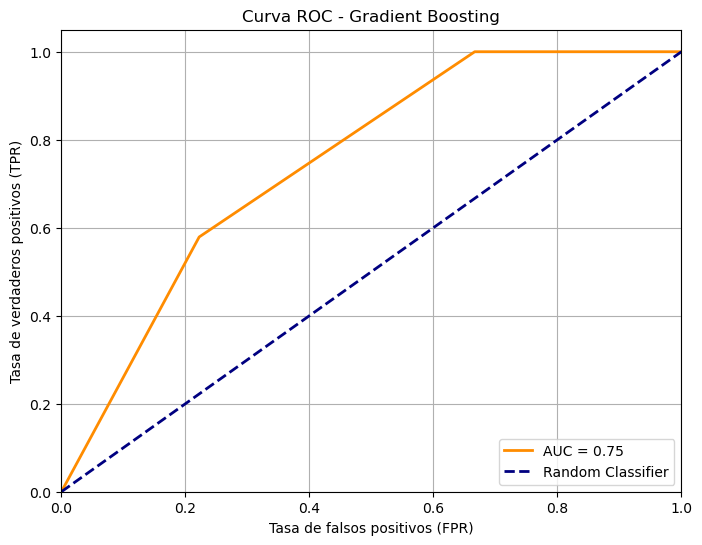

R^2 train: 0.86
R^2 test: 0.68
Accuracy: 0.68
AUC de la curva ROC: 0.7485
Tasa de verdaderos negativos (TNR - especificidad): 0.6667
Tasa de falsos negativos (FNR): 0.3158
Tasa de verdaderos positivos (TPR): 0.6842
Tasa de falsos positivos (FPR): 0.3333

Importancia de variables:
      Feature  Importance
1         H19    0.580229
0  TNRC6C-AS1    0.233851
2   MBNL1-AS1    0.185920


In [12]:
# Hiperparámetros
n_estimators = 100
max_depth = 3

# Datos
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

# Discretización
X_train = discretizar_variables(X_train, 2)
X_test = discretizar_variables(X_test, 2)

# Renombrar columnas
rename_map = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}
X_train = X_train.rename(columns=rename_map)[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]
X_test = X_test.rename(columns=rename_map)[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]

# Modelo Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
gb.fit(X_train, y_train)

# Predicciones
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)
y_test_proba = gb.predict_proba(X_test)[:, 1]

# Importancia de variables
importances = gb.feature_importances_
feature_names = X_train.columns
feat_importances = pd.DataFrame(importances, index=feature_names).reset_index() \
                    .rename(columns={'index': 'Feature', 0: 'Importance'}) \
                    .sort_values(by='Importance', ascending=False)

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Matriz de confusión
TN, FP, FN, TP = confusion_matrix(y_test, y_test_pred).ravel()
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

# Gráfico ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Métricas de rendimiento
r2_train = gb.score(X_train, y_train)
r2_test = gb.score(X_test, y_test)
accuracy = accuracy_score(y_test, y_test_pred)

print(f'R^2 train: {r2_train:.2f}')
print(f'R^2 test: {r2_test:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print(f"AUC de la curva ROC: {roc_auc:.4f}")
print(f"Tasa de verdaderos negativos (TNR - especificidad): {TNR:.4f}")
print(f"Tasa de falsos negativos (FNR): {FNR:.4f}")
print(f"Tasa de verdaderos positivos (TPR): {TPR:.4f}")
print(f"Tasa de falsos positivos (FPR): {FPR:.4f}")
print("\nImportancia de variables:")
print(feat_importances)

# Cross-validation (opcional, pero con advertencia: CV sobre test no es habitual)
accuracies_train = cross_val_score(gb, X_train, y_train)
accuracies_test = cross_val_score(gb, X_test, y_test)

# Guardar en diccionario global
algortms_tasas.update({
    'Gradient Boosting': {
        'Accuracy': accuracy,
        'AUC': roc_auc,
        'R^2 train': r2_train,
        'R^2 test': r2_test,
        'TNR': TNR,
        'FNR': FNR,
        'TPR': TPR,
        'FPR': FPR
    }
})

importancias.update({'Gradient Boosting': feat_importances}) 

### Naive Bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB
#import roc_auc_score
from sklearn.metrics import accuracy_score
import numpy as np 


AUC: 0.75
R^2 train: 0.69
R^2 test: 0.68
Tasa de verdaderos negativos (TNR - especificidad): 0.0
Tasa de falsos negativos (FNR): 0.0
Tasa de verdaderos  positivos (TPR): 1.0
Tasa de falsos positivos (FPR): 1.0
      Feature    Importance
1         H19  4.660897e-01
2   MBNL1-AS1 -3.522206e-01
0  TNRC6C-AS1 -2.220446e-16


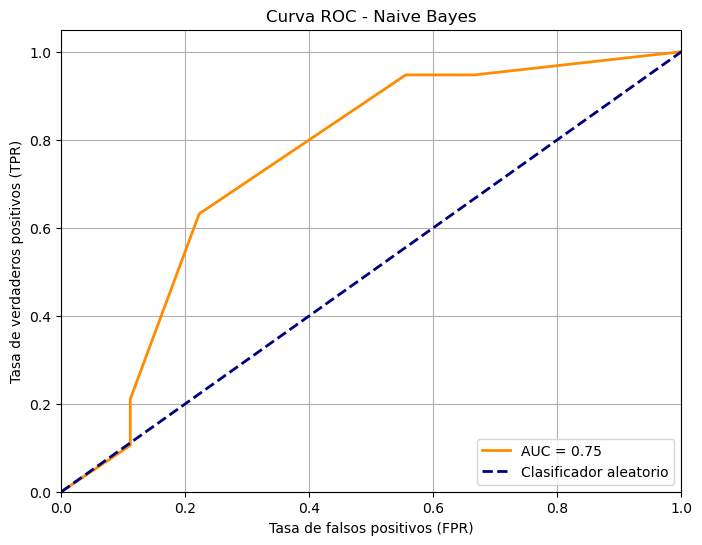

In [14]:
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
X_test = discretizar_variables(X_test, 2)
# Renombrar columnas
rename_map = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}
X_train = X_train.rename(columns=rename_map)[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]
X_test = X_test.rename(columns=rename_map)[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]


naive_bayes = MultinomialNB ().fit(X_train, y_train)
y_pred = naive_bayes.predict(X_test)
y_proba = naive_bayes.predict_proba(X_test)[:, 1] 
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': naive_bayes.feature_log_prob_[1] - naive_bayes.feature_log_prob_[0]
})
feature_importances['Importance_abs'] = feature_importances['Importance'].abs()
feature_importances = feature_importances.sort_values('Importance_abs',ascending=False)
feature_importances.drop('Importance_abs', axis=1, inplace=True)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')
r_squared = naive_bayes.score(X_train, y_train)
print(f'R^2 train: {r_squared:.2f}')
r_squared = naive_bayes.score(X_test, y_test)
print(f'R^2 test: {r_squared:.2f}')
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Métricas adicionales
TNR = TN / (TN + FP) if (TN + FP) > 0 else np.nan  # Specificity
FNR = FN / (FN + TP) if (FN + TP) > 0 else np.nan  # False Negative Rate
TPR = TP / (TP + FN) if (TP + FN) > 0 else np.nan
FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan

print("Tasa de verdaderos negativos (TNR - especificidad):", TNR)
print("Tasa de falsos negativos (FNR):", FNR)
print("Tasa de verdaderos  positivos (TPR):", TPR)
print("Tasa de falsos positivos (FPR):", FPR)
print(feature_importances)
# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


algortms_tasas.update({'Neive_Bayes': {'Accuracy': accuracy,
                                      'AUC': roc_auc, 'R^2 train': r_squared,
                                      'R^2 test': r_squared, 'TNR': TNR,
                                      'FNR': FNR, 'TPR': TPR, 'FPR': FPR}})

importancias.update({'Neive_Bayes': feature_importances}) 


In [15]:
imp = {}
for model, importance in importancias.items():
    imp[model] = {importance ['Feature'][i]: importance['Importance'][i] for i in range(len(importance))}


In [16]:
pd.DataFrame(imp).T[['H19','TNRC6C-AS1', 'MBNL1-AS1']].T

,Random Forest,Logistica,Gradient Boosting,Neive_Bayes
H19,0.472045,0.526075,0.580229,4.660897e-01
TNRC6C-AS1,0.295771,0.000000,0.233851,-2.220446e-16
MBNL1-AS1,0.232184,0.000000,0.185920,-3.522206e-01


In [37]:
(pd.DataFrame(algortms_tasas))

,Random Forest,Logistica,Gradient Boosting,Neive_Bayes
Accuracy,0.678571,0.678571,0.678571,0.678571
AUC,0.774854,0.704678,0.748538,0.745614
R^2 train,0.678571,0.678571,0.857143,0.678571
R^2 test,0.678571,0.678571,0.678571,0.678571
TNR,0.666667,0.777778,0.666667,0.000000
FNR,0.315789,0.368421,0.315789,0.000000
TPR,0.684211,0.631579,0.684211,1.000000
FPR,0.333333,0.222222,0.333333,1.000000


### Regresión

In [ ]:
import statsmodels.api as sm

In [ ]:
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
X_test = discretizar_variables(X_test, 2)

X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

X = X.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'})
X = X[['TNRC6C-AS1', 'H19', 'MBNL1-AS1']]

X = sm.add_constant(X) 


reg = sm.OLS(y, X).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Grupo_Tratamiento   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     5.477
Date:                Wed, 16 Jul 2025   Prob (F-statistic):            0.00218
Time:                        10:51:07   Log-Likelihood:                -33.480
No. Observations:                  63   AIC:                             74.96
Df Residuals:                      59   BIC:                             83.53
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4720      0.086      5.458      0.000       0.299       0.645
TNRC6C-AS1    -0.0057      0.122     -0.047      0.963      -0.249       0.238
H19            0.4394      0.125      3.504      0.001       0.188       0.690
MBNL1-AS1     -0.0057      0.122     -0.047      0.963      -0.249       0.238
==============================================================================
Omnibus:                        4.550   Durbin-Watson:                   0.713
Prob(Omnibus):                  0.103   Jarque-Bera (JB):                3.154
Skew:                          -0.388   Prob(JB):                        0.207
Kurtosis:                       2.226   Cond. No.                         3.77
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Red Bayesiana

In [11]:
from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator,BIC
from pgmpy.models import DiscreteBayesianNetwork 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

In [12]:
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
df_train = pd.concat([X_train, y_train], axis=1)
X_test = discretizar_variables(X_test, 2)
df_test = pd.concat([X_test, y_test], axis=1)
df_train = df_train[[ 'TNRC6C-AS1_1', 'H19_1', 'MBNL1-AS1_1', 'Grupo_Tratamiento']]
df_train.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}, inplace=True)
df_test = df_test[[ 'TNRC6C-AS1_1', 'H19_1', 'MBNL1-AS1_1', 'Grupo_Tratamiento']]
df_test.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}, inplace=True)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

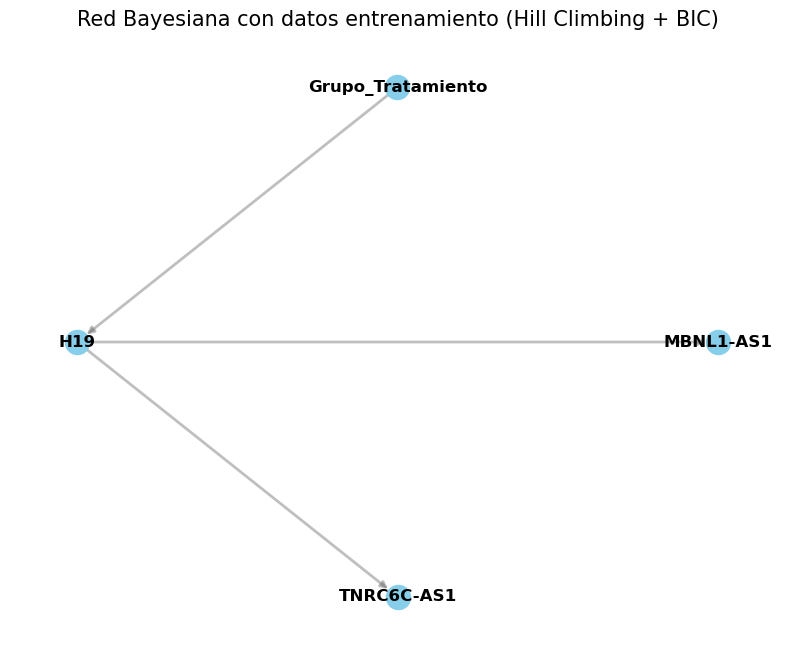

In [13]:
hc = HillClimbSearch(df_train)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.shell_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana con datos entrenamiento (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

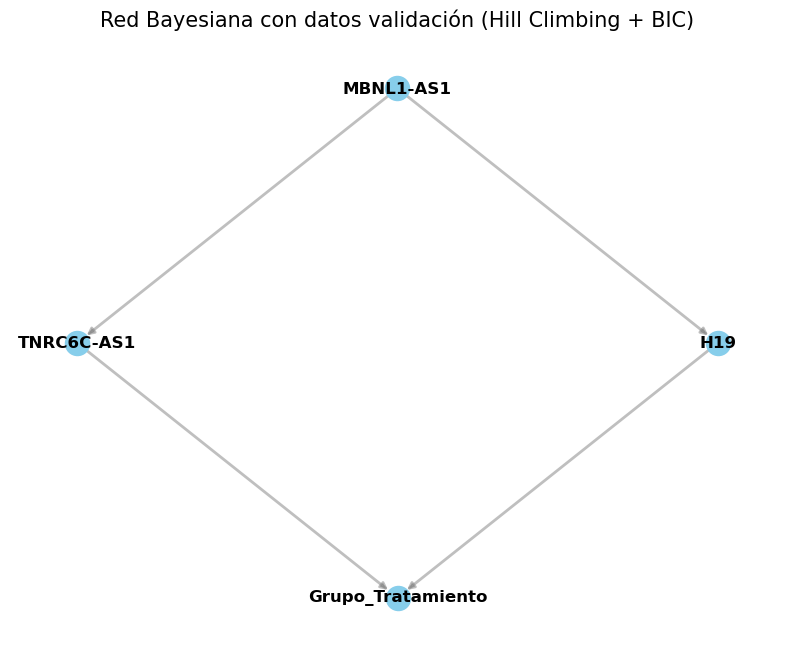

In [33]:
hc = HillClimbSearch(df_test)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.shell_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana con datos validación (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

con todos los datos

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

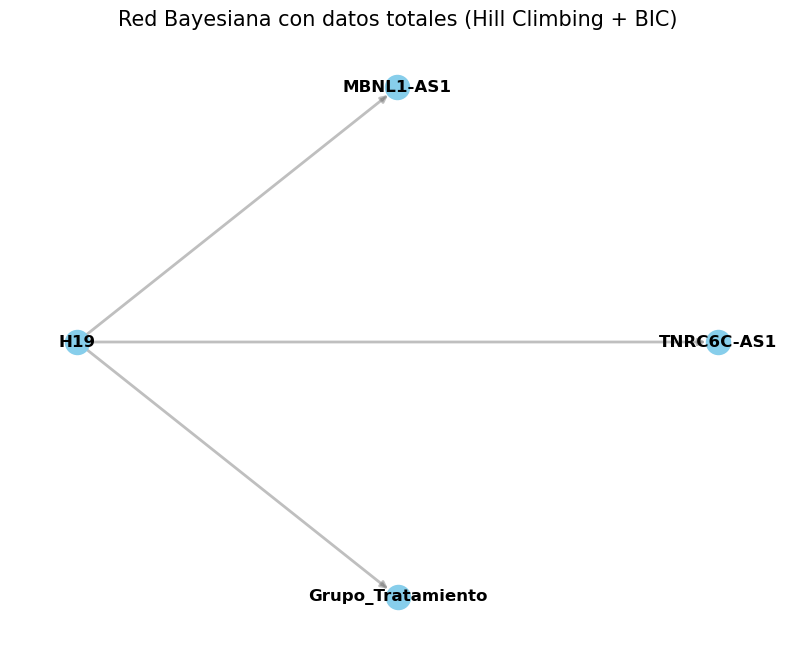

In [14]:
df = pd.concat([df_train, df_test], axis=0)

hc = HillClimbSearch(df)
best_model = hc.estimate(scoring_method='bic-d')

edges = best_model.edges()
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(10, 8))  # Tamaño del gráfico
pos = nx.shell_layout(G)  # Layout de la red (puedes cambiar el tipo)
nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

# Mostrar el gráfico
plt.title("Red Bayesiana con datos totales (Hill Climbing + BIC)", size=15)
plt.axis('off')  # Quitar los ejes para mejor presentación
plt.show()

#### Predicción con red bayesiana

In [15]:

from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork 


In [16]:
X_train = lncRNA_entrenamiento_norm_1.drop(columns=["Grupo_Tratamiento"])
X_test = lncRNA_validacion_norm_1.drop(columns=["Grupo_Tratamiento"])
y_train = lncRNA_entrenamiento_norm_1["Grupo_Tratamiento"]
y_test = lncRNA_validacion_norm_1["Grupo_Tratamiento"]

X_train = discretizar_variables(X_train, 2)
df_train = pd.concat([X_train, y_train], axis=1)
X_test = discretizar_variables(X_test, 2)
df_test = pd.concat([X_test, y_test], axis=1)
df_train = df_train[[ 'TNRC6C-AS1_1', 'H19_1', 'MBNL1-AS1_1', 'Grupo_Tratamiento']]
df_train.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}, inplace=True)
df_test = df_test[[ 'TNRC6C-AS1_1', 'H19_1', 'MBNL1-AS1_1', 'Grupo_Tratamiento']]
df_test.rename(columns = {'TNRC6C-AS1_1': 'TNRC6C-AS1', 'H19_1': 'H19', 'MBNL1-AS1_1': 'MBNL1-AS1'}, inplace=True)
df = pd.concat([df_train, df_test], axis=0)

In [17]:
hc = HillClimbSearch(df)
best_model = hc.estimate(scoring_method='bic-d')


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

In [18]:
model = DiscreteBayesianNetwork (best_model.edges())
model.fit(df_train, estimator=BayesianEstimator, prior_type='BDeu')

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


In [19]:
infer = VariableElimination(model)

for i in [[0,0,0],[0,1,0],[1,0,0],[1,1,0],[0,0,1],[0,1,1],[1,0,1],[1,1,1]]:
    print(f"TNRC6C-AS1: {i[0]}, H19: {i[1]}, MBNL1-AS1: {i[2]}")
    query_result = infer.query(
        variables=["Grupo_Tratamiento"],
        evidence={
            "TNRC6C-AS1": i[0],
            "H19": i[1],
            "MBNL1-AS1": i[2]
        }
    )
    print(query_result)


TNRC6C-AS1: 0, H19: 0, MBNL1-AS1: 0
+----------------------+--------------------------+
| Grupo_Tratamiento    |   phi(Grupo_Tratamiento) |
+======================+==========================+
| Grupo_Tratamiento(0) |                   0.5488 |
+----------------------+--------------------------+
| Grupo_Tratamiento(1) |                   0.4512 |
+----------------------+--------------------------+
TNRC6C-AS1: 0, H19: 1, MBNL1-AS1: 0
+----------------------+--------------------------+
| Grupo_Tratamiento    |   phi(Grupo_Tratamiento) |
+======================+==========================+
| Grupo_Tratamiento(0) |                   0.1154 |
+----------------------+--------------------------+
| Grupo_Tratamiento(1) |                   0.8846 |
+----------------------+--------------------------+
TNRC6C-AS1: 1, H19: 0, MBNL1-AS1: 0
+----------------------+--------------------------+
| Grupo_Tratamiento    |   phi(Grupo_Tratamiento) |
+======================+==========================+
| Grupo_

In [20]:
infer = VariableElimination(model)

results = {}
for i in [[0,0,0],[0,1,0],[1,0,0],[1,1,0],[0,0,1],[0,1,1],[1,0,1],[1,1,1]]:
    query_result = infer.query(
        variables=["Grupo_Tratamiento"],
        evidence={
            "TNRC6C-AS1": i[0],
            "H19": i[1],
            "MBNL1-AS1": i[2]
        }
    )
    results[f"TNRC6C-AS1: {i[0]}, H19: {i[1]}, MBNL1-AS1: {i[2]}"] = query_result.values


In [21]:
pd.DataFrame(results).T

,0,1
"TNRC6C-AS1: 0, H19: 0, MBNL1-AS1: 0",0.548780,0.451220
"TNRC6C-AS1: 0, H19: 1, MBNL1-AS1: 0",0.115385,0.884615
"TNRC6C-AS1: 1, H19: 0, MBNL1-AS1: 0",0.548780,0.451220
"TNRC6C-AS1: 1, H19: 1, MBNL1-AS1: 0",0.115385,0.884615
"TNRC6C-AS1: 0, H19: 0, MBNL1-AS1: 1",0.548780,0.451220
"TNRC6C-AS1: 0, H19: 1, MBNL1-AS1: 1",0.115385,0.884615
"TNRC6C-AS1: 1, H19: 0, MBNL1-AS1: 1",0.548780,0.451220
"TNRC6C-AS1: 1, H19: 1, MBNL1-AS1: 1",0.115385,0.884615


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = []
y_pred = []

for i, row in df_test.iterrows():
    evidencia = row.drop("Grupo_Tratamiento").to_dict()  # resto de variables
    resultado = infer.query(variables=["Grupo_Tratamiento"], evidence=evidencia)
    clase_predicha = resultado.values.argmax()
    y_pred.append(clase_predicha)
    y_true.append(row["Grupo_Tratamiento"])

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.6785714285714286


Acabamos de probar hill climbing, ahora vamos a probar otros y calcular sus ccuracies
tabu, pc, grow-shrink, iamb, inter-iamb, rsmax2

In [45]:
from pgmpy.estimators import HillClimbSearch, BIC, PC, ExhaustiveSearch, GES, MmhcEstimator



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fro

  0%|          | 0/1000000 [00:00<?, ?it/s]

Model: Hill Climbing


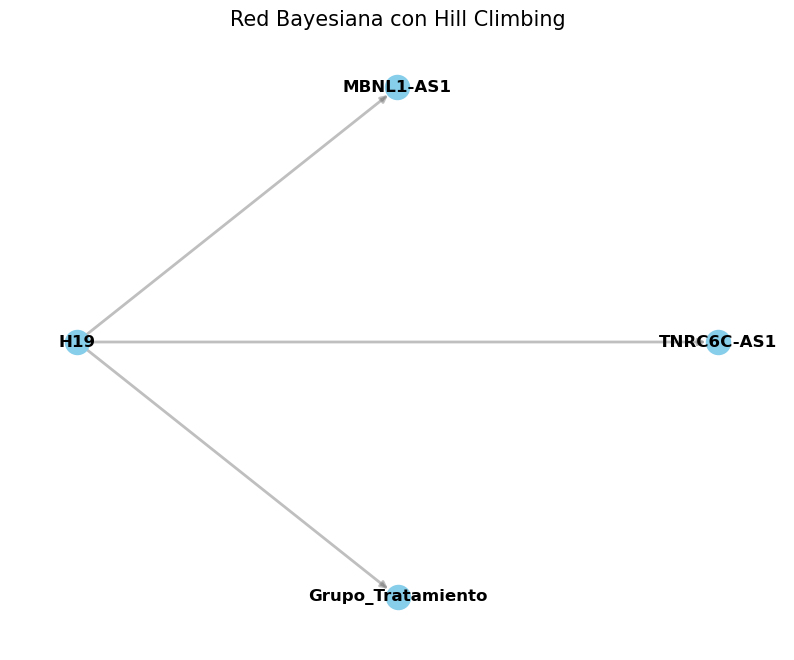

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


Model: PC


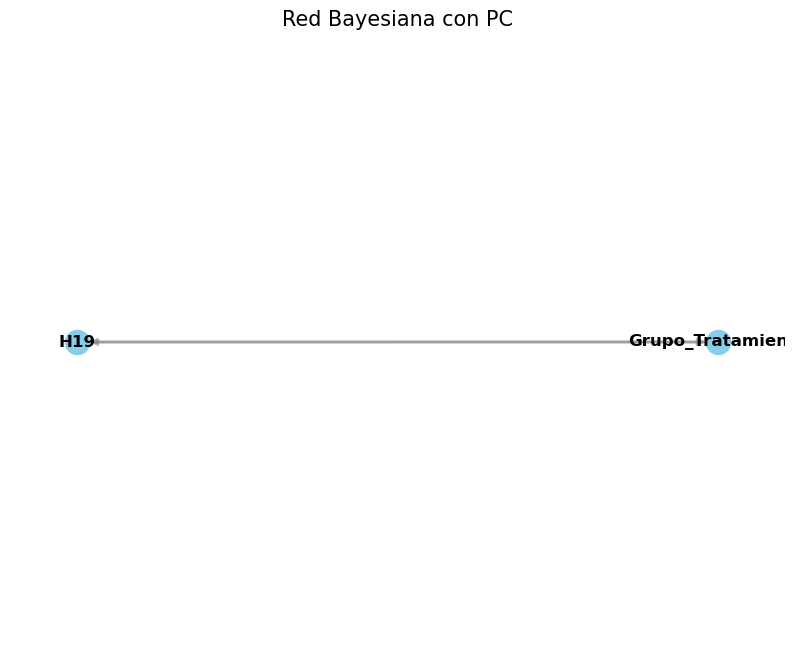

¡El grafo tiene ciclos!
Model: GES


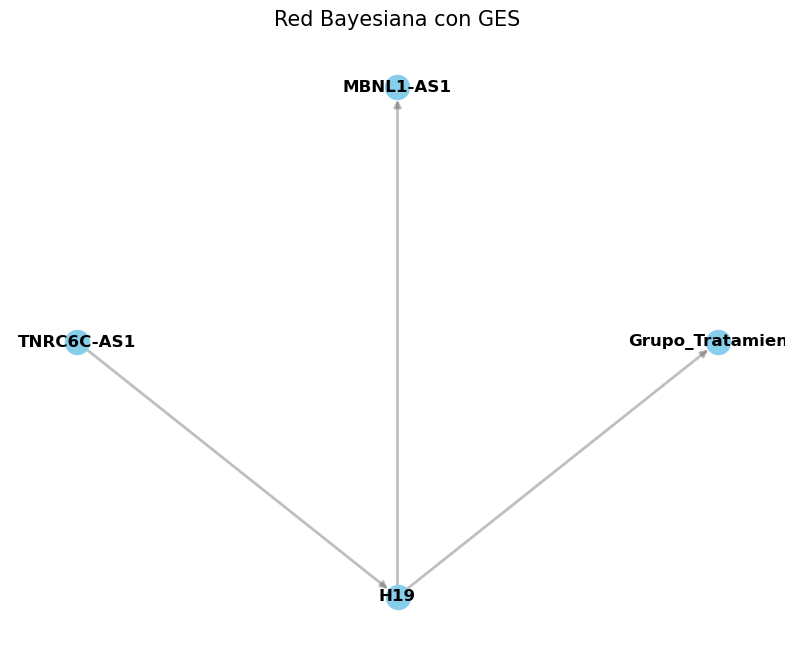

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


Model: Exhaustive Search


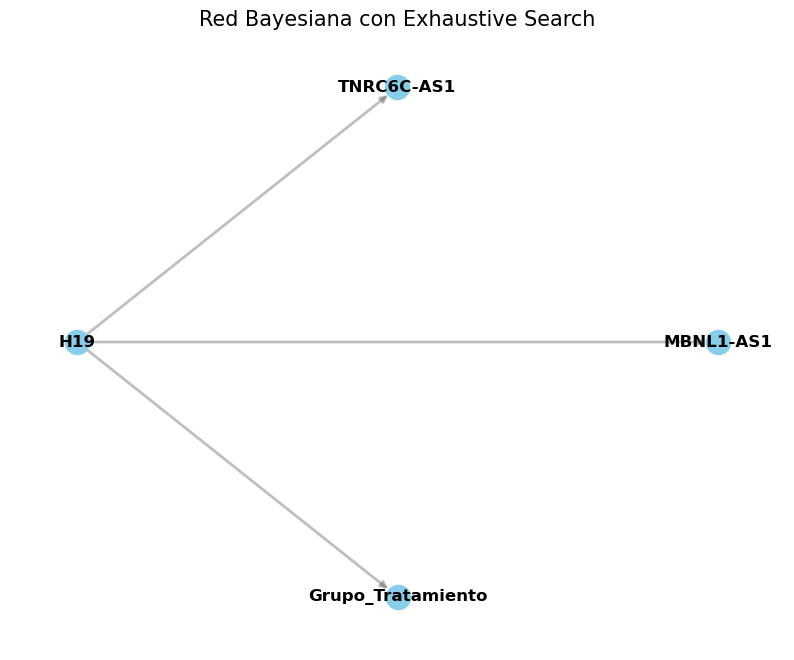

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


Model: MMHC


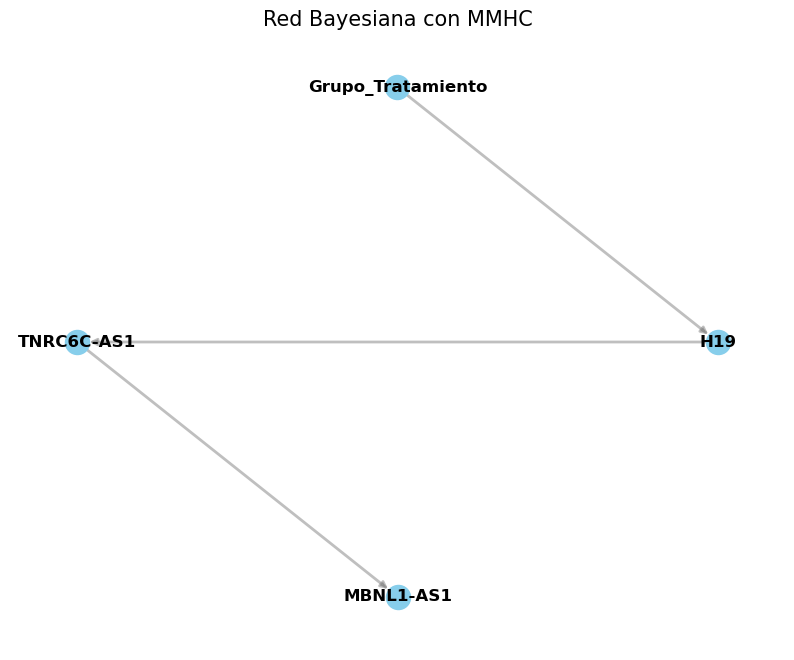

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


In [46]:
# Búsqueda hill climbing con BIC
hc = HillClimbSearch(df)
hc_model = hc.estimate(scoring_method=BIC(df))

# Algoritmo PC
pc = PC(df)
pc_model = pc.estimate(significance_level=0.05)

# Algoritmo GES (Greedy Equivalence Search)
ges = GES(df)
ges_model = ges.estimate(scoring_method=BIC(df))

# Algoritmo Exhaustive Search 
scoring = BIC(df)
exh = ExhaustiveSearch(df, scoring_method=scoring)
exh_model = exh.estimate()

# Algoritmo MMHC (Método híbrido)
mmhc = MmhcEstimator(df)
mmhc_model = mmhc.estimate(scoring_method=BIC(df))


models = {
    "Hill Climbing": hc_model, 'PC': pc_model,
    "GES": ges_model, "Exhaustive Search": exh_model, "MMHC": mmhc_model}
accuracies_test = {}
scores = {}
for i in models:
    model = models[i]
    print(f"Model: {i}")
    edges = list(model.edges())
    G = nx.DiGraph(edges)
    G.add_edges_from(edges)

    plt.figure(figsize=(10, 8))  # Tamaño del gráfico
    pos = nx.shell_layout(G)  # Layout de la red (puedes cambiar el tipo)
    nx.draw_networkx_nodes(G, pos,  node_color="skyblue")  # Dibujar los nodos
    nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.5, edge_color="gray",arrows = True)  # Dibujar las aristas
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_color="black")  # Etiquetas

    # Mostrar el gráfico
    plt.title(f"Red Bayesiana con {i}", size=15)
    plt.axis('off')  # Quitar los ejes para mejor presentación
    plt.show()
    if not nx.is_directed_acyclic_graph(G):
        print("¡El grafo tiene ciclos!")
        accuracies_test[i] = None
        continue
    else:
        BN_model = DiscreteBayesianNetwork(model.edges())
        BN_model.fit(df_train, estimator=BayesianEstimator, prior_type='BDeu')
        infer = VariableElimination(BN_model)

        y_true = []
        y_pred = []
        score = BIC(df_train).score(model)
        scores[i] = score
            
        resultado = infer.query(variables=["Grupo_Tratamiento"], evidence={"TNRC6C-AS1": 0,"H19":1,"MBNL1-AS1": 0})
        clase_predicha = resultado.values.argmax()
        accuracy = resultado.values[1]
        accuracies_test[i] = accuracy

#### Validación cruzada

In [ ]:
hc = HillClimbSearch(df)
hc_model = hc.estimate(scoring_method=BIC(df))

# Algoritmo PC
pc = PC(df)
pc_model = pc.estimate(significance_level=0.05)

# Algoritmo GES (Greedy Equivalence Search)
ges = GES(df)
ges_model = ges.estimate(scoring_method=BIC(df))

# Algoritmo Exhaustive Search 
scoring = BIC(df)
exh = ExhaustiveSearch(df, scoring_method=scoring)
exh_model = exh.estimate()

# Algoritmo MMHC (Método híbrido)
mmhc = MmhcEstimator(df)
mmhc_model = mmhc.estimate(scoring_method=BIC(df))

In [74]:
from sklearn.model_selection import KFold
scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(df):
    print(f"Train indices: {train_idx}, Test indices: {test_idx}")

Train indices: [ 1  2  3  4  6  7  8 10 11 13 14 15 17 18 19 20 21 22 23 24 26 27 28 29
 30 31 32 33 34 35 37 38 39 41 42 44 45 46 47 48 49 50 51 52 53 54 56 58
 59 62], Test indices: [ 0  5  9 12 16 25 36 40 43 55 57 60 61]
Train indices: [ 0  1  2  5  7  9 10 11 12 14 15 16 18 20 21 22 23 24 25 26 27 28 29 30
 31 32 35 36 37 38 39 40 41 42 43 44 45 47 50 51 52 54 55 56 57 58 59 60
 61 62], Test indices: [ 3  4  6  8 13 17 19 33 34 46 48 49 53]
Train indices: [ 0  1  2  3  4  5  6  7  8  9 10 12 13 14 16 17 18 19 20 21 22 23 25 28
 29 33 34 35 36 37 38 39 40 42 43 44 46 47 48 49 50 51 52 53 55 56 57 60
 61 62], Test indices: [11 15 24 26 27 30 31 32 41 45 54 58 59]
Train indices: [ 0  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 24 25 26 27
 28 30 31 32 33 34 36 38 40 41 42 43 45 46 48 49 51 52 53 54 55 57 58 59
 60 61 62], Test indices: [ 1  2 21 23 29 35 37 39 44 47 50 56]
Train indices: [ 0  1  2  3  4  5  6  8  9 11 12 13 15 16 17 19 21 23 24 25 26 27 29 30
 31 32 33 34

In [75]:
def cross_validate_bayes_net(data, target, algoritmo, k=5):
    from sklearn.model_selection import KFold
    scores = []
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(data):
        df_train = data.iloc[train_idx]
        df_test = data.iloc[test_idx]

        # Aprender estructura
        if algoritmo == "hc":
            hc = HillClimbSearch(df)
            model = hc.estimate(scoring_method=BIC(df))
        if algoritmo == "pc":
            pc = PC(df)
            model = pc.estimate(significance_level=0.05)
        if algoritmo == "ges":
            ges = GES(df)
            model = ges.estimate(scoring_method=BIC(df))
        if algoritmo == "exhaustive":
            scoring = BIC(df)
            exh = ExhaustiveSearch(df, scoring_method=scoring)
            model = exh.estimate()
        if algoritmo == "mmhc":
            mmhc = MmhcEstimator(df)
            model = mmhc.estimate(scoring_method=BIC(df))
        edges = list(model.edges())
        G = nx.DiGraph(edges)
        if not nx.is_directed_acyclic_graph(G):
            return None
        else:
            # Construir y ajustar modelo
            bn_model = DiscreteBayesianNetwork(model.edges())
            bn_model.fit(df_train, estimator=BayesianEstimator, prior_type="BDeu")

            # Inferencia
            infer = VariableElimination(bn_model)

            y_true = []
            y_pred = []

            for _, row in df_test.iterrows():
                evidence = row.drop(target).to_dict()
                try:
                    resultado = infer.query([target], evidence=evidence, show_progress=False)
                    pred = resultado.values.argmax()
                    y_pred.append(pred)
                    y_true.append(row[target])
                except:
                    continue  # saltar si hay evidencia inconsistente

            if y_true:
                sc = BIC(df_test).score(model)
                scores.append(sc)

    return scores


In [79]:
algoritmos = ["hc", "pc", "ges", "exhaustive", "mmhc"]
resultados_cv = {}  
for algoritmo in algoritmos:
    accuracies = cross_validate_bayes_net(df, "Grupo_Tratamiento", algoritmo,10)
    resultados_cv[algoritmo] = {
        "mean_accuracy": np.mean(accuracies) if accuracies else None,
        "std_accuracy": np.std(accuracies) if accuracies else None,
        "accuracies": accuracies 
    }   
    

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fro

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred fro

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TNRC6C-AS1': 'N', 'H19': 'N', 'MBNL1-AS1': 'N', 'Grupo_Tratamiento': 'N'}


C:\Users\delatorrei\AppData\Local\Temp\ipykernel_8072\3793066339.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True)


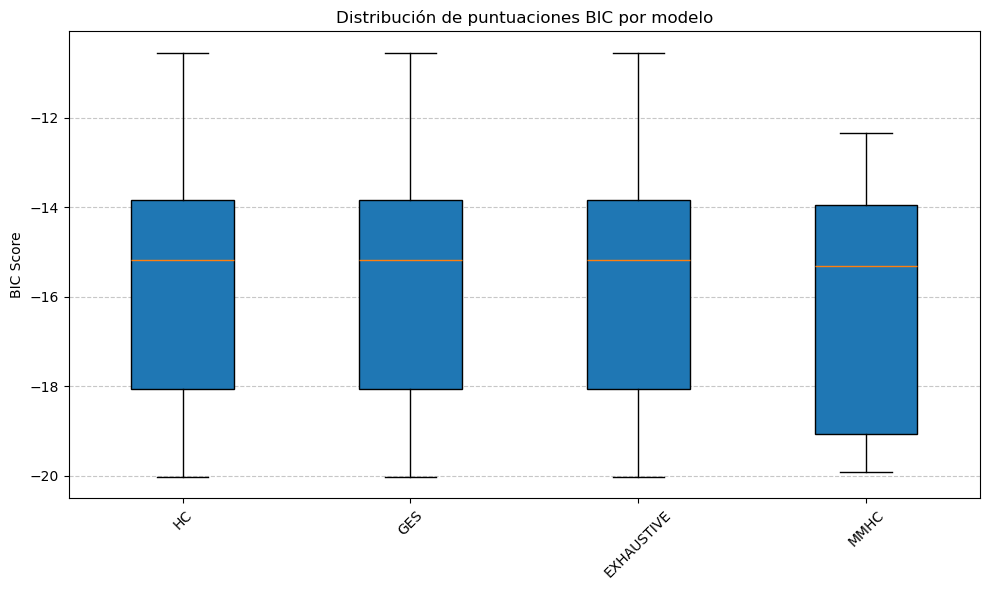

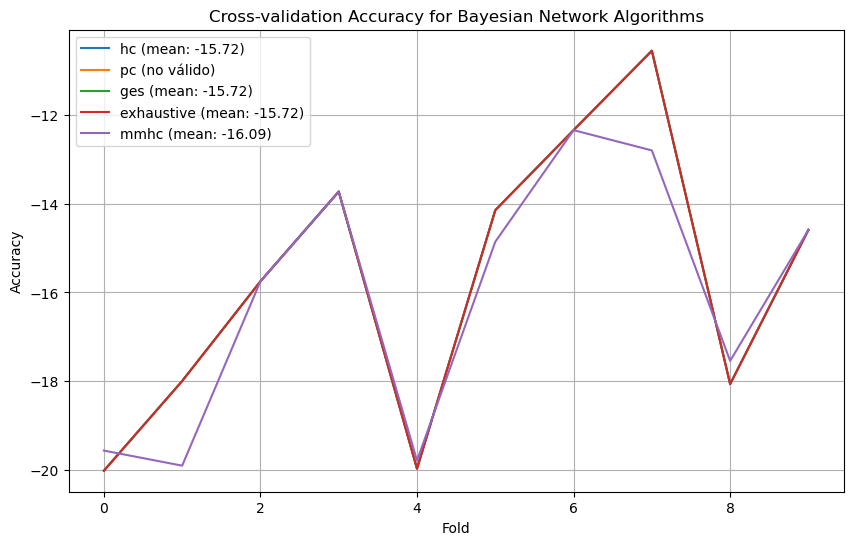

In [83]:
labels = []
data = []

for model_name, info in resultados_cv.items():
    if info['accuracies'] is not None:
        labels.append(model_name.upper())
        data.append(info['accuracies'])

# Hacemos el gráfico
plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title("Distribución de puntuaciones BIC por modelo")
plt.ylabel("BIC Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for algoritmo, resultados in resultados_cv.items():
    if resultados["mean_accuracy"] is not None:
        plt.plot(resultados["accuracies"], label=f"{algoritmo} (mean: {resultados['mean_accuracy']:.2f})")
        plt.legend()
        plt.xlabel('Fold')
        plt.ylabel('Accuracy')
        plt.title('Cross-validation Accuracy for Bayesian Network Algorithms')
        plt.grid(True)
    else:
        plt.plot([], [], label=f"{algoritmo} (no válido)")
plt.show()